# Loan Approval Prediction

You are given a dataset containing information about loan applicants (e.g., income, employment status, credit history, loan amount, etc.). Target variable: `Loan_Status`.

* Exploratory Data Analysis (EDA)

    * Inspect dataset shape, columns, and types
    * Check for missing values
    * Visualize distributions of key variables
    * Explore relationships between features and loan status

* Data Preprocessing
    * Handle missing values appropriately
    * Encode categorical variables
    * Normalize/scale numeric features if necessary
    * Split the dataset into train/test sets

* Model Building

    * Train a Logistic Regression model
    * Explain why Logistic Regression is suitable for this problem
    * Fit the model on training data

* Model Evaluation
    * Evaluate the model using accuracy, precision, recall, F1-score, confusion matrix, ROC curve and AUC score
    * Explain what each metric tells you about model performance

* Interpretation
    * Identify the most influential features
    * Interpret model coefficients
    * Explain what increases or decreases the probability of loan approval

* Improvement (Optional Bonus)

Try at least one improvement:
    * Feature engineering
    * Class imbalance handling
    * Hyperparameter tuning
    * Comparing with another classifier

In [1]:
import csv
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Read data
df_loans = pd.read_csv("LoanApprovalPrediction.csv")
df_loans.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Drop the Loan_ID column
df_loans.drop(["Loan_ID"], axis=1, inplace=True)

In [4]:
# Snake_case is common in database design, so all column names are converted to it to simplify the workflow
df_loans = df_loans.rename(columns={
    'Gender': 'gender',
    'Married': 'married',
    'Dependents': 'dependents',
    'Education': 'education',
    'Self_Employed': 'self_employed',
    'ApplicantIncome': 'applicant_income',
    'CoapplicantIncome': 'coapplicant_income',
    'LoanAmount': 'loan_amount', 
    'Loan_Amount_Term': 'loan_term',
    'Credit_History': 'credit_history',
    'Property_Area': 'property_area',
    'Loan_Status': 'loan_status'
})

In [5]:
df_loans.head()

,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_term,credit_history,property_area,loan_status
0,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 1. Exploratory Data Analysis

In [6]:
df_loans.shape

(598, 12)

In [7]:
df_loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              598 non-null    object 
 1   married             598 non-null    object 
 2   dependents          586 non-null    float64
 3   education           598 non-null    object 
 4   self_employed       598 non-null    object 
 5   applicant_income    598 non-null    int64  
 6   coapplicant_income  598 non-null    float64
 7   loan_amount         577 non-null    float64
 8   loan_term           584 non-null    float64
 9   credit_history      549 non-null    float64
 10  property_area       598 non-null    object 
 11  loan_status         598 non-null    object 
dtypes: float64(5), int64(1), object(6)
memory usage: 56.2+ KB


In [8]:
df_loans.describe()

,dependents,applicant_income,coapplicant_income,loan_amount,loan_term,credit_history
count,586.000000,598.000000,598.000000,577.000000,584.000000,549.000000
mean,0.755973,5292.252508,1631.499866,144.968804,341.917808,0.843352
std,1.007751,5807.265364,2953.315785,82.704182,65.205994,0.363800
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.000000,360.000000,1.000000
50%,0.000000,3806.000000,1211.500000,127.000000,360.000000,1.000000
75%,1.750000,5746.000000,2324.000000,167.000000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,650.000000,480.000000,1.000000


In [9]:
# Check for missing values
missing_values = pd.DataFrame({
    'column': df_loans.columns,
    'missing values': df_loans.isnull().sum().values,
    'missing_percent': (df_loans.isnull().sum() / len(df_loans) * 100).round(2)
})

missing_values = missing_values.sort_values('missing_percent', ascending=False)
print('Missing values\n')
print(missing_values.to_string(index=False))

Missing values

            column  missing values  missing_percent
    credit_history              49             8.19
       loan_amount              21             3.51
         loan_term              14             2.34
        dependents              12             2.01
            gender               0             0.00
           married               0             0.00
         education               0             0.00
     self_employed               0             0.00
  applicant_income               0             0.00
coapplicant_income               0             0.00
     property_area               0             0.00
       loan_status               0             0.00


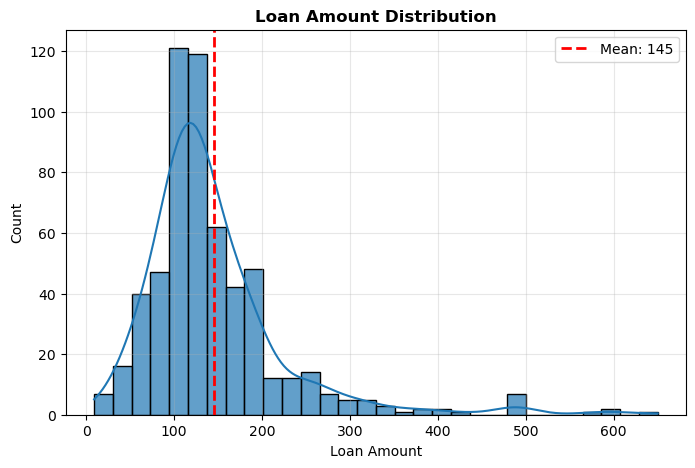

In [10]:
# Loan amount distribution
plt.figure(figsize=(8, 5))

mean_loan = df_loans['loan_amount'].mean()

sns.histplot(data=df_loans, x='loan_amount', bins=30, kde=True, edgecolor='black', alpha=0.7)

plt.title('Loan Amount Distribution', fontweight='bold')
plt.xlabel('Loan Amount')
plt.ylabel('Count')
line = plt.axvline(mean_loan, color='red', linestyle='dashed', linewidth=2)
plt.legend([line], [f'Mean: {mean_loan:,.0f}'])
plt.grid(True, alpha=0.3)
plt.show()

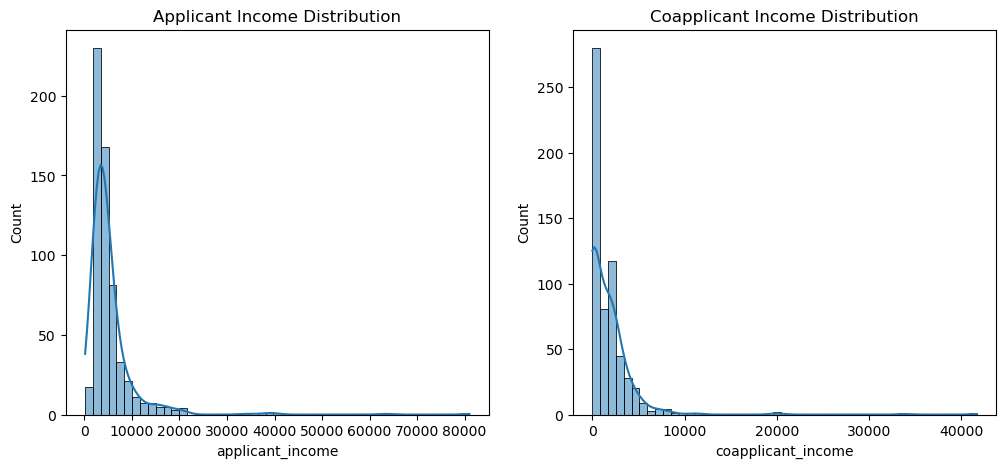

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Applicant income distribution
sns.histplot(df_loans['applicant_income'], kde=True, edgecolor='black', ax=axes[0])
axes[0].set_title('Applicant Income Distribution')

# Coapplicant income distributiion
sns.histplot(df_loans['coapplicant_income'], kde=True, edgecolor='black', ax=axes[1])
axes[1].set_title('Coapplicant Income Distribution')

plt.show()

> The **loan_amount**, **applicant_income**, and **coapplicant_income** distributions are right-skewed, so these columns are candidates for log transformation.

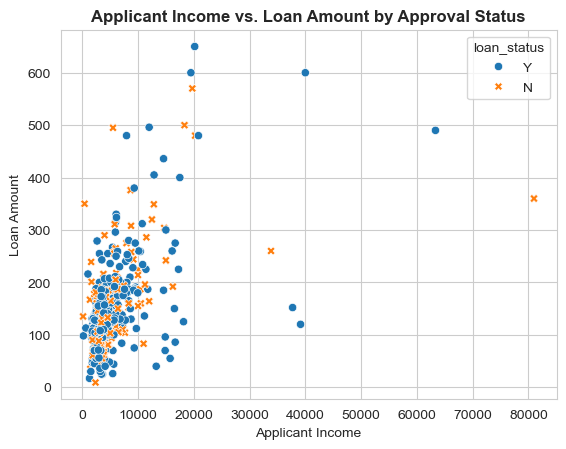

In [12]:
# Applicant Income vs. Loan Amount by Approval Status
sns.set_style("whitegrid")
sns.scatterplot(df_loans, x="applicant_income", y="loan_amount", hue="loan_status", style="loan_status")
plt.title('Applicant Income vs. Loan Amount by Approval Status', fontweight='bold')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.show()

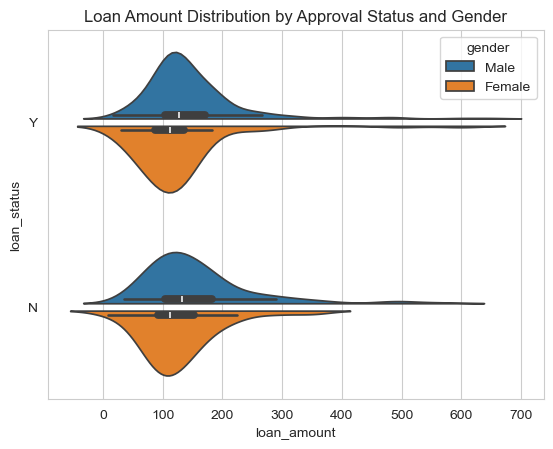

In [13]:
# Loan Amount Distribution by Approval Status and Gender
sns.violinplot(data=df_loans, x='loan_amount', y='loan_status', hue='gender', split=True, gap=.1)
plt.title('Loan Amount Distribution by Approval Status and Gender')
plt.show()

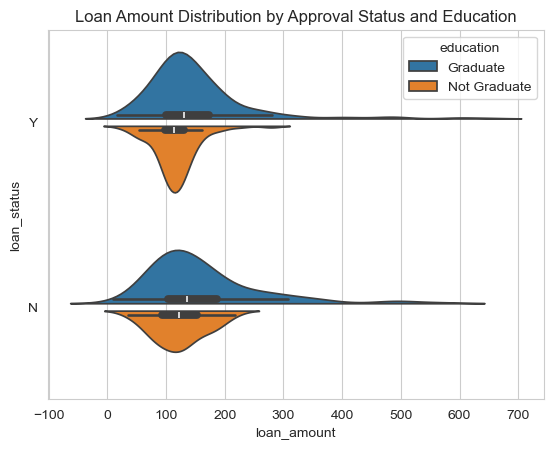

In [14]:
# Loan Amount Distribution by Approval Status and Education
sns.violinplot(data=df_loans, x='loan_amount', y='loan_status', hue='education', split=True, gap=.1)
plt.title('Loan Amount Distribution by Approval Status and Education')
plt.show()

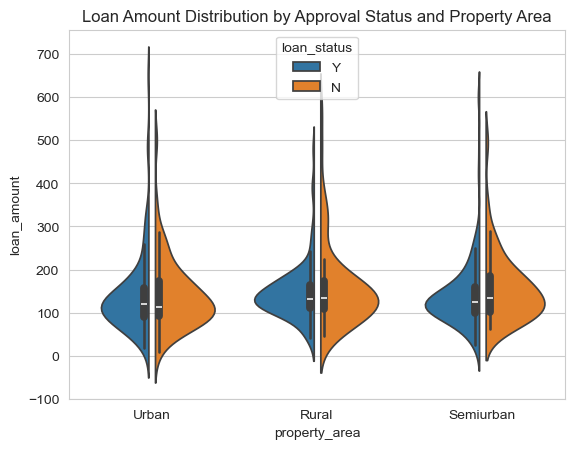

In [15]:
# Loan Amount Distribution by Approval Status and Property Area
sns.violinplot(data=df_loans, x='property_area', y='loan_amount', split=True, gap=.1, hue='loan_status')
plt.title('Loan Amount Distribution by Approval Status and Property Area')
plt.show()

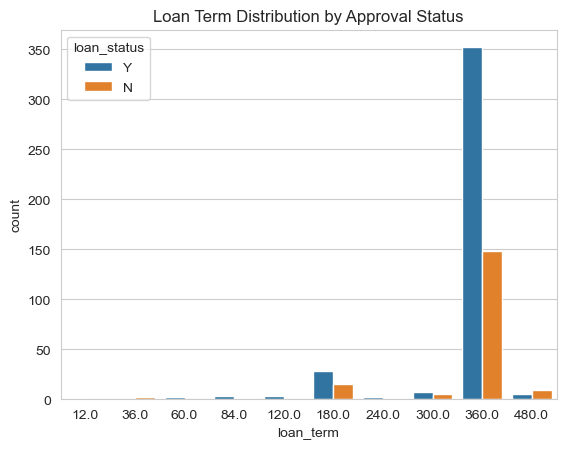

In [16]:
# Loan Term Distribution by Approval Status
sns.countplot(df_loans, x="loan_term", hue="loan_status")
plt.title('Loan Term Distribution by Approval Status')
plt.show()

In [17]:
# Convert loan_term into categorical variable
df_loans["loan_term"] = df_loans["loan_term"].astype('category')

## 2. Data Preprocessing

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [19]:
numeric_cols = ["applicant_income", "coapplicant_income", "loan_amount"]

# Check for missing values in numeric columns
df_loans[numeric_cols].isnull().sum()

applicant_income       0
coapplicant_income     0
loan_amount           21
dtype: int64

In [20]:
# Pipeline for numeric columns
numeric_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(missing_values=np.nan, strategy='median')),
    ("log1p", FunctionTransformer(np.log1p, validate=True, feature_names_out='one-to-one')),
    ("scale", StandardScaler())
])

In [21]:
# Check the numeric pipeline
numeric_transformed = numeric_pipeline.fit_transform(df_loans[numeric_cols])
numeric_transformed_df = pd.DataFrame(numeric_transformed, columns=numeric_cols)
numeric_transformed_df.head()

,applicant_income,coapplicant_income,loan_amount
0,0.539391,-1.110999,-0.013951
1,0.152174,0.779053,0.001994
2,-0.520462,-1.110999,-1.340341
3,-0.758008,0.894429,-0.129186
4,0.579856,-1.110999,0.198728


In [22]:
binary_cols = ["gender", "married", "education", "self_employed", "credit_history"]

for col in binary_cols:
    print(df_loans[col].value_counts())
    print(f"Missing values in {col} column: {df_loans[col].isnull().sum()}")

gender
Male      487
Female    111
Name: count, dtype: int64
Missing values in gender column: 0
married
Yes    388
No     210
Name: count, dtype: int64
Missing values in married column: 0
education
Graduate        465
Not Graduate    133
Name: count, dtype: int64
Missing values in education column: 0
self_employed
No     488
Yes    110
Name: count, dtype: int64
Missing values in self_employed column: 0
credit_history
1.0    463
0.0     86
Name: count, dtype: int64
Missing values in credit_history column: 49


In [23]:
def map_binary_cols(X):
    X = X.copy()

    mapping_dict = {
    'gender': {'Male': 1, 'Female': 0},
    'married': {'Yes': 1, 'No': 0},
    'education': {'Graduate': 1, 'Not Graduate': 0},
    'self_employed': {'Yes': 1, 'No': 0}
    }

    for col, mapping in mapping_dict.items():
        X[col] = X[col].map(mapping)

    return X

In [24]:
binary_preprocessor = ColumnTransformer([
    ('binary_mapper', FunctionTransformer(
        map_binary_cols,
        feature_names_out=lambda self, names: ["gender", "married", "education", "self_employed"]
    ), ["gender", "married", "education", "self_employed"]),
    # Fill missing credit history with the mode value
    ('credit_imputer', SimpleImputer(strategy='most_frequent'), ["credit_history"])
])

# Pipeline for binary columns
binary_pipeline = Pipeline(steps=[
    ('preprocessor', binary_preprocessor)
])

In [25]:
# Check the binary pipeline
binary_transformed = binary_pipeline.fit_transform(df_loans[binary_cols])
binary_transformed_df = pd.DataFrame(binary_transformed, columns=binary_cols)
binary_transformed_df.head()

,gender,married,education,self_employed,credit_history
0,1.0,0.0,1.0,0.0,1.0
1,1.0,1.0,1.0,0.0,1.0
2,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,0.0,0.0,1.0
4,1.0,0.0,1.0,0.0,1.0


In [26]:
print(df_loans["dependents"].value_counts())
print("Missing values in dependents column:", df_loans['dependents'].isna().sum())

dependents
0.0    338
1.0    101
2.0     99
3.0     48
Name: count, dtype: int64
Missing values in dependents column: 12


In [27]:
def create_dependents_dummies(X):
    X = X.copy()
    
    X["dependents"] = X["dependents"].fillna(0).astype(int)
    
    return pd.get_dummies(X["dependents"], prefix="dependents", drop_first=True).astype(int)

In [28]:
# Pipeline for dependents
dependents_pipeline = Pipeline([
    ('dependents', FunctionTransformer(
        create_dependents_dummies,
        feature_names_out=lambda self, names: ["dependents_1", "dependents_2", "dependents_3"]
    ))
])

In [29]:
# Check the dependents pipeline
dependents_transformed = dependents_pipeline.fit_transform(df_loans[["dependents"]])
dependents_transformed_df = pd.DataFrame(dependents_transformed)
dependents_transformed_df.head()

,dependents_1,dependents_2,dependents_3
0,0,0,0
1,1,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [30]:
# Pipeline for property_area
property_area_pipeline = Pipeline([
    ('dummies', FunctionTransformer(
        lambda X: pd.get_dummies(X["property_area"], prefix="area", drop_first=True)
                    .rename(columns=lambda x: x.lower()),
        feature_names_out=lambda self, names: ["area_semiurban", "area_urban"]
    ))
])

In [31]:
# Check the property pipeline
property_area_transformed = property_area_pipeline.fit_transform(df_loans[["property_area"]])
property_area_transformed_df = pd.DataFrame(property_area_transformed)
property_area_transformed_df.head()

,area_semiurban,area_urban
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [32]:
# Pipeline for loan_term
loan_term_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        sparse_output=False,
        drop='first',
        handle_unknown='ignore',
        categories='auto'
    ))
])

In [33]:
# Check the loan pipeline
loan_term_transformed = loan_term_pipeline.fit_transform(df_loans[["loan_term"]])
loan_term_transformed_df = pd.DataFrame(loan_term_transformed)
loan_term_transformed_df.head()

,0,1,2,3,4,5,6,7,8
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [34]:
logreg_preprocessor = ColumnTransformer([
    ('binary', binary_pipeline, ["gender", "married", "education", "self_employed", "credit_history"]),
    ('numeric', numeric_pipeline, ["applicant_income", "coapplicant_income", "loan_amount"]),
    ('dependents', dependents_pipeline, ["dependents"]),
    ('property', property_area_pipeline, ["property_area"]),
    ('term', loan_term_pipeline, ["loan_term"])
])

## 3. Logistic Regression Model Building and Evaluation

Logistic regression models are specifically designed to predict the probability of a binary outcome, which is exactly our case: we need to know if the loan will be approved or rejected based on credit history, income, and other parameters. 
    
Using logistic regression is a good strategy for this task because it offers a clear and easily interpretable link between input features and the final decision.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [36]:
X = df_loans.drop('loan_status', axis=1)
y = df_loans['loan_status'].map({'Y': 1, 'N': 0})

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [38]:
logreg_unbalanced = Pipeline(steps=[
    ('preprocessor', logreg_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight=None, random_state=42))
])

logreg_unbalanced.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('binary', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

### Model Coefficients Interpretation

In [39]:
intercept = logreg_unbalanced.named_steps['classifier'].intercept_
coefficients = logreg_unbalanced.named_steps['classifier'].coef_
print("Intercept:", intercept )
print("Coefficients:", coefficients)

Intercept: [-2.98403453]
Coefficients: [[-0.11921245  0.47216543  0.33562129 -0.09517055  3.30916258  0.17489502
   0.1504532  -0.29160425 -0.44024604  0.29400934  0.07913842  0.66886156
   0.21688311 -0.92828789  0.24587486  0.33389208  0.13754617  0.33597621
  -0.04538183  0.05525222  0.2872052  -0.60306755]]


In [40]:
feature_names = logreg_preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': logreg_unbalanced.named_steps['classifier'].coef_[0]
})

coef_df['feature'] = coef_df['feature'].str.split('__').str[-1]

coef_df_sorted = coef_df.sort_values(by='coef', key=lambda x: abs(x), ascending=False)

print(coef_df_sorted)

               feature      coef
4       credit_history  3.309163
13      loan_term_36.0 -0.928288
11      area_semiurban  0.668862
21     loan_term_480.0 -0.603068
1              married  0.472165
8         dependents_1 -0.440246
17     loan_term_180.0  0.335976
2            education  0.335621
15      loan_term_84.0  0.333892
9         dependents_2  0.294009
7          loan_amount -0.291604
20     loan_term_360.0  0.287205
14      loan_term_60.0  0.245875
12          area_urban  0.216883
5     applicant_income  0.174895
6   coapplicant_income  0.150453
16     loan_term_120.0  0.137546
0               gender -0.119212
3        self_employed -0.095171
10        dependents_3  0.079138
19     loan_term_300.0  0.055252
18     loan_term_240.0 -0.045382


In [41]:
top_positive = coef_df[coef_df['coef'] > 0].sort_values('coef', ascending=False).head(5)
print("\nTop 5 features that increase loan approval odds\n")
print(top_positive)


Top 5 features that increase loan approval odds

            feature      coef
4    credit_history  3.309163
11   area_semiurban  0.668862
1           married  0.472165
17  loan_term_180.0  0.335976
2         education  0.335621


In [42]:
top_negative = coef_df[coef_df['coef'] < 0].sort_values(by='coef', key=lambda x: abs(x), ascending=False).head(5)
print("\nTop 5 features that decrease loan approval odds\n")
print(top_negative)


Top 5 features that decrease loan approval odds

            feature      coef
13   loan_term_36.0 -0.928288
21  loan_term_480.0 -0.603068
8      dependents_1 -0.440246
7       loan_amount -0.291604
0            gender -0.119212


### Model Evaluation

In [43]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

In [44]:
y_pred = logreg_unbalanced.predict(X_test)
y_pred_proba = logreg_unbalanced.predict_proba(X_test)[:, 1]

print("Confusion matrix for logreg model\n", confusion_matrix(y_test, y_pred))

Confusion matrix for logreg model
 [[17 21]
 [ 2 80]]


In [45]:
logreg_roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {logreg_roc_auc:.4f}")
print("\nClassification Report for logreg_unbalanced Model:")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.8309

Classification Report for logreg_unbalanced Model:
              precision    recall  f1-score   support

           0       0.89      0.45      0.60        38
           1       0.79      0.98      0.87        82

    accuracy                           0.81       120
   macro avg       0.84      0.71      0.74       120
weighted avg       0.82      0.81      0.79       120



### Unbalanced Logistic Regression Model Performance

Correct Predictions (97 total):
* 80 correctly approved loans (TP)
* 17 correctly rejected loans (TN)

Incorrect Predictions (23 total):
* 21 false positives (21 high-risk borrowers mistakenly approved)
* 2 false negatives (2 creditworthy borrowers mistakenly rejected)

This logistic regression model shows strong performance in identifying creditworthy applicants (98%), but has limitations in identifying high-risk candidates (recall is only 45%, and f1-score is 0.6). Thus, the model is biased towards approval.

When the model approves the loan, it's correct in 79% of cases. When it comes to declining the loan, the model is even more precise: 89%.

## Unbalanced Logistic Regression Model Cross-Validation

In [46]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.model_selection import cross_val_score
import warnings

In [47]:
# Ignore warnings related to loan_term values appearing only in certain folders
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.preprocessing')

In [48]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [49]:
cv_scores_unbalanced = cross_val_score(logreg_unbalanced, X_train, y_train, cv=cv, scoring='roc_auc')

In [50]:
print("Cross-validation of unbalanced logreg model\n")
print(f"ROC-AUC scores: {np.round(cv_scores_unbalanced, 4)}")
print(f"Min ROC-AUC score: {min(cv_scores_unbalanced):.4f}")
print(f"Mean ROC-AUC: {cv_scores_unbalanced.mean():.4f}")

Cross-validation of unbalanced logreg model

ROC-AUC scores: [0.8616 0.6434 0.7045 0.7031 0.7283]
Min ROC-AUC score: 0.6434
Mean ROC-AUC: 0.7282


### Cross Validation Results Interpretation

Cross validation results indicate that the model performance is highly unstable: it depends heavily on how the data is split.

## 4. Class imbalance Handling

Let's look at how balancing classes affects model performance.

In [51]:
logreg_balanced = Pipeline(steps=[
    ('preprocessor', logreg_preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

logreg_balanced.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('binary', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [52]:
y_pred = logreg_balanced.predict(X_test)
y_pred_proba = logreg_balanced.predict_proba(X_test)[:, 1]

In [72]:
roc_auc_balanced = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc_balanced:.4f}")
print("\nClassification Report for balanced logreg model:")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.8296

Classification Report for balanced logreg model:
              precision    recall  f1-score   support

           0       0.89      0.45      0.60        38
           1       0.79      0.98      0.87        82

    accuracy                           0.81       120
   macro avg       0.84      0.71      0.74       120
weighted avg       0.82      0.81      0.79       120



In [73]:
cv_scores_balanced = cross_val_score(logreg_balanced, X_train, y_train, cv=cv, scoring='roc_auc')

In [74]:
print("Cross-validation of balanced logreg model\n")
print(f"ROC-AUC scores: {np.round(cv_scores_balanced, 4)}")
print(f"Min ROC-AUC score: {min(cv_scores_balanced):.4f}")
print(f"Mean ROC-AUC: {cv_scores_balanced.mean():.4f}")

Cross-validation of balanced logreg model

ROC-AUC scores: [0.8571 0.6495 0.7051 0.6979 0.7356]
Min ROC-AUC score: 0.6495
Mean ROC-AUC: 0.7290


> For model with balanced classes, the worst-case scenario and mean ROC-AUC are slightly better comparing to the unbalanced model.

## 5. Comparing with Other Classifier: Decision Tree

In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [64]:
numeric_pipeline_no_scale = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

In [65]:
tree_preprocessor = ColumnTransformer([
    ('binary', binary_pipeline, ['gender', 'married', 'education', 'self_employed', 'credit_history']),
    ('numeric', numeric_pipeline_no_scale, ['applicant_income', 'coapplicant_income', 'loan_amount']),
    ('dependents', dependents_pipeline, ['dependents']),
    ('property', property_area_pipeline, ['property_area']),
    ('term', loan_term_pipeline, ['loan_term'])
])

In [66]:
dt = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        max_depth=3,
        criterion='entropy'
    ))
])

dt.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('binary', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [67]:
cv_scores_dt = cross_val_score(dt, X_train, y_train, cv=cv, scoring='roc_auc')

In [68]:
print("Cross-validation of decision tree model\n")
print(f"ROC-AUC scores: {np.round(cv_scores_dt, 4)}")
print(f"Min ROC-AUC score: {min(cv_scores_dt):.4f}")
print(f"Mean ROC-AUC: {cv_scores_dt.mean():.4f}")

Cross-validation of decision tree model

ROC-AUC scores: [0.7944 0.5609 0.7159 0.619  0.6769]
Min ROC-AUC score: 0.5609
Mean ROC-AUC: 0.6734


## 6. Model Comparison

In [69]:
from sklearn.metrics import make_scorer, f1_score, roc_auc_score

In [70]:
models_data = {
    'logreg_unbalanced': {
        'scores': cv_scores_unbalanced.tolist(),  # преобразуем в список
        'min': np.min(cv_scores_unbalanced),
        'mean': np.mean(cv_scores_unbalanced)
    },
    'logreg_balanced': {
        'scores': cv_scores_balanced.tolist(),
        'min': np.min(cv_scores_balanced),
        'mean': np.mean(cv_scores_balanced)
    },
    'dt': {
        'scores': cv_scores_dt.tolist(),
        'min': np.min(cv_scores_dt),
        'mean': np.mean(cv_scores_dt)
    }
}

In [71]:
print("ROC-AUC Comparison for Different Models")
for model_name, data in models_data.items():
    print(f"\n{model_name} model")
    print(f"Scores: {[f'{x:.4f}' for x in data['scores']]}")
    print(f"Min: {data['min']:.4f}")
    print(f"Mean: {data['mean']:.4f}")

ROC-AUC Comparison for Different Models

logreg_unbalanced model
Scores: ['0.8616', '0.6434', '0.7045', '0.7031', '0.7283']
Min: 0.6434
Mean: 0.7282

logreg_balanced model
Scores: ['0.8571', '0.6495', '0.7051', '0.6979', '0.7356']
Min: 0.6495
Mean: 0.7290

dt model
Scores: ['0.7944', '0.5609', '0.7159', '0.6190', '0.6769']
Min: 0.5609
Mean: 0.6734


> **logreg_balanced** model seems to have the best performance.

### Model Performance on Test Data: logreg_balanced

In [68]:
best_model = logreg_balanced

In [69]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

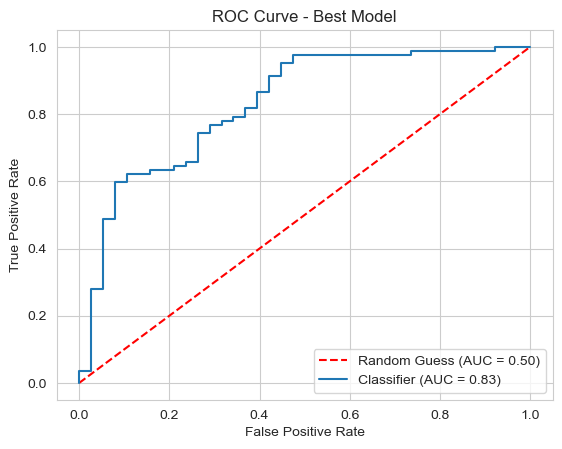

In [73]:
# Best Model ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess (AUC = 0.50)')
plt.plot(fpr, tpr, label=f"Classifier (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Model')
plt.legend(loc='lower right')
plt.show()

In [75]:
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}\n")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.8296

              precision    recall  f1-score   support

           0       0.75      0.55      0.64        38
           1       0.82      0.91      0.86        82

    accuracy                           0.80       120
   macro avg       0.78      0.73      0.75       120
weighted avg       0.79      0.80      0.79       120



In [76]:
print("Confusion matrix for balanced logreg model\n", confusion_matrix(y_test, y_pred))

Confusion matrix for balanced logreg model
 [[21 17]
 [ 7 75]]


## Conclusion

Correct Predictions (96 total):
* 75 correctly approved loans (TP)
* 21 correctly rejected loans (TN)

Incorrect Predictions (24 total):
* 17 false positives (17 high-risk borrowers mistakenly approved)
* 7 false negatives (7 creditworthy borrowers mistakenly rejected)
  
Even though the best (balanced) model mistakenly rejects creditworthy users more often (2 → 7), it correctly identifies more high-risk borrowers (17 → 21 true rejections), making it a better fit for credit scoring where approving a bad borrower is more critical than rejecting a good one.